***Simulations de Modèles de carnets d'ordres***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps


In [2]:
LAMBDA_PLUS = 1.2
LAMBDA_MINUS = 2
T = 100
Q_0 = 10
Q_0_B = 10
Q_0_A = 10

def simulate_only_one_process(lambda_plus, lambda_minus, q_0=Q_0_A):
    q = q_0
    times = [0]
    q_values = [q]
    while q > 0:
        total_rate = lambda_plus + lambda_minus
        time_to_next_event = np.random.exponential(1 / total_rate)
        times.append(times[-1] + time_to_next_event)
        if np.random.rand() < lambda_plus / total_rate:
            q += 1
        else:
            q -= 1
        q_values.append(q)
    return times, q_values


def simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a = Q_0_A, q_0_b = Q_0_B):
    times_b, q_b_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0_b)
    times_a, q_a_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0_a)
    return times_b, q_b_values, times_a, q_a_values

def plot_poisson_process(times_b, q_b_values, times_a, q_a_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.tight_layout()
    plt.grid()
    plt.show()


def plot_combined(times_b, q_b_values, times_a, q_a_values):
    plt.figure()
    plt.plot(times_b, q_b_values, label='q_b')
    plt.plot(times_a, q_a_values, label='q_a')
    plt.title('Évolution de q_b et q_a au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('Quantité')
    plt.grid()
    plt.legend()
    plt.show()



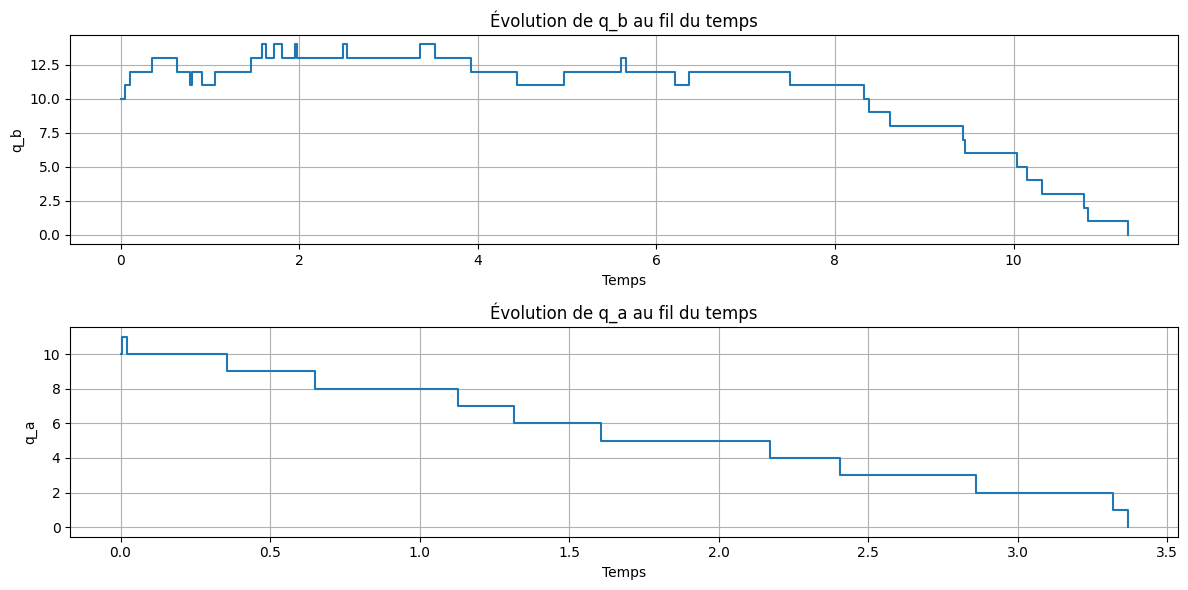

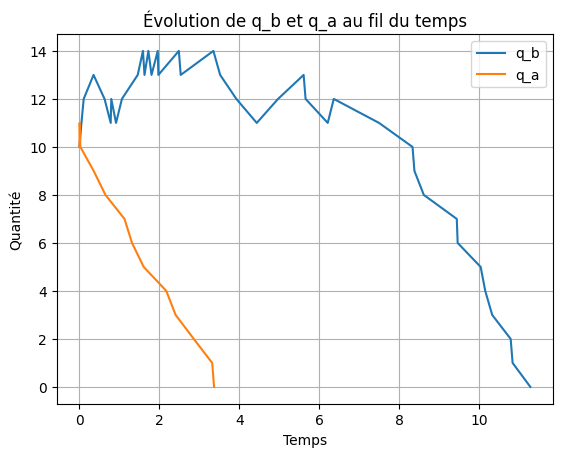

In [3]:
times_b, q_b_values, times_a, q_a_values = simulate_poisson_process_until_zero(LAMBDA_PLUS, LAMBDA_MINUS)
plot_poisson_process(times_b, q_b_values, times_a, q_a_values)
plot_combined(times_b, q_b_values, times_a, q_a_values)

In [34]:
def estimate_time_to_zero(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000, quantile = 0.95):
    times_to_zero = []
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a, q_0_b)
        times_to_zero.append(min(times_b[-1], times_a[-1]))
    estimate = np.mean(times_to_zero)
    z_score = sps.norm.ppf((1+quantile)/2)
    upper_IC_bound = estimate + z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    lower_IC_bound = estimate - z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    print (f"Temps moyen estimé pour que q_a ou q_b atteigne zéro : {estimate:.2f} unités de temps")
    print(f"Intervalle de confiance à {quantile*100:.0f}% pour le temps moyen : [{lower_IC_bound}, {upper_IC_bound}]")
    return estimate, lower_IC_bound, upper_IC_bound

def estimate_time_to_zero_for_one_process(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=1000, quantile = 0.95):
    times_to_zero = []
    for _ in range(num_simulations):
        q = q_0
        time = 0
        while q > 0:
            total_rate = lambda_plus + lambda_minus
            time_to_next_event = np.random.exponential(1 / total_rate)
            time += time_to_next_event
            if np.random.rand() < lambda_plus / total_rate:
                q += 1
            else:
                q -= 1
        times_to_zero.append(time)
    estimate = np.mean(times_to_zero)
    z_score = sps.norm.ppf((1+quantile)/2)
    upper_IC_bound = estimate + z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    lower_IC_bound = estimate - z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    print (f"Temps moyen estimé pour que le processus {q_0},{lambda_minus},{lambda_plus} atteigne zéro : {estimate:.2f} unités de temps")
    print(f"Intervalle de confiance à {quantile*100:.0f}% pour le temps moyen du processus {q_0},{lambda_minus},{lambda_plus} : [{lower_IC_bound}, {upper_IC_bound}]")
    return estimate, lower_IC_bound, upper_IC_bound

In [35]:
estimate1, lower_IC_bound1, upper_IC_bound1 = estimate_time_to_zero(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, quantile=0.95)
estimate1, lower_IC_bound1, upper_IC_bound1 = estimate_time_to_zero_for_one_process(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, quantile=0.95)

Temps moyen estimé pour que q_a ou q_b atteigne zéro : 8.46 unités de temps
Intervalle de confiance à 95% pour le temps moyen : [8.197977435324185, 8.724896216181117]
Temps moyen estimé pour que le processus 10,2,1.2 atteigne zéro : 12.56 unités de temps
Intervalle de confiance à 95% pour le temps moyen du processus 10,2,1.2 : [12.064372319328605, 13.053443789328675]


In [36]:
def trajectory_grid(times_b, q_b_values, times_a, q_a_values):
    tb = np.array(times_b)
    ta = np.array(times_a)
    qb = np.array(q_b_values)
    qa = np.array(q_a_values)

    # O(n log n) merge: for each event time, find the last known q_b and q_a via binary search
    t_stop = min(tb[-1], ta[-1])                                     
    all_times = np.sort(np.concatenate([ta, tb]))
    all_times = all_times[all_times <= t_stop]
    q_B = qb[np.searchsorted(tb, all_times, side='right') - 1]
    q_A = qa[np.searchsorted(ta, all_times, side='right') - 1]

    # Count visits per (bid, ask) grid point
    points = np.stack([q_B, q_A], axis=1)
    _, inverse, unique_counts = np.unique(points, axis=0, return_inverse=True, return_counts=True)
    counts = unique_counts[inverse].astype(float)

    # Rare points → transparent, frequent points → opaque
    min_alpha = 0.5
    span = counts.max() - counts.min()
    alphas = min_alpha + (1 - min_alpha) * (counts - counts.min()) / (span if span > 0 else 1)

    rgba = np.column_stack([
        np.full(len(q_B), 0.2),
        np.full(len(q_B), 0.4),
        np.full(len(q_B), 0.8),
        alphas,
    ])

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(q_B, q_A, color='blue', alpha=0.5, linewidth=0.5, zorder=1)
    ax.scatter(q_B[1:-1], q_A[1:-1], c=rgba[1:-1], s=40, zorder=2)
    ax.set_title('Trajectoire de (Bid, Ask) dans le plan')
    plt.scatter([q_B[0]], [q_A[0]], s=40, zorder=2, c='red', label='Début')
    plt.scatter([q_B[-1]], [q_A[-1]], s=40, zorder=2, c='green', label='Fin')
    plt.legend()
    ax.set_xlabel('Bid (q_b)')
    ax.set_ylabel('Ask (q_a)')
    plt.grid(alpha=0.3)
    plt.show()


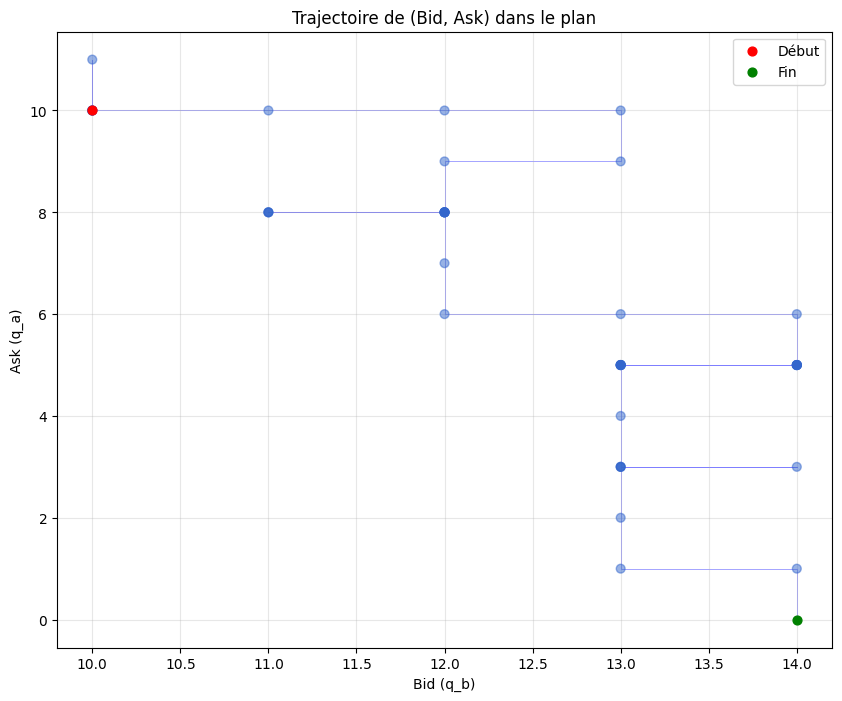

In [37]:
trajectory_grid(times_b, q_b_values, times_a, q_a_values)

In [38]:
#Showing that Q_a can be approximated by a Brownian motion with drift lambda_plus - lambda_minus and variance lambda_plus + lambda_minus
def plot_approximation(T, lambda_plus, lambda_minus, num_simulations=1000, q_0 = Q_0_A):
    drift = lambda_plus - lambda_minus
    variance = lambda_plus + lambda_minus
    samples = []
    for _ in range(num_simulations):
        q = q_0
        t = 0
        while t < T:
            dt = np.random.exponential(1 / (lambda_plus + lambda_minus))
            t += dt
            q += 1 if np.random.rand() < lambda_plus / (lambda_plus + lambda_minus) else -1
        samples.append(q)
    plt.figure(figsize=(10, 6))
    plt.hist(samples, bins='auto', density=True, alpha=0.6, color='g', label='Simulations')
    x = np.linspace(min(samples), max(samples), 100)
    plt.plot(x, sps.norm.pdf(x, loc=q_0 + drift * T, scale=np.sqrt(variance * T)), 'r-', label='Approximation normale')
    plt.xlabel('q')
    plt.ylabel('Densité')
    plt.title('Distribution de q à l\'instant T')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


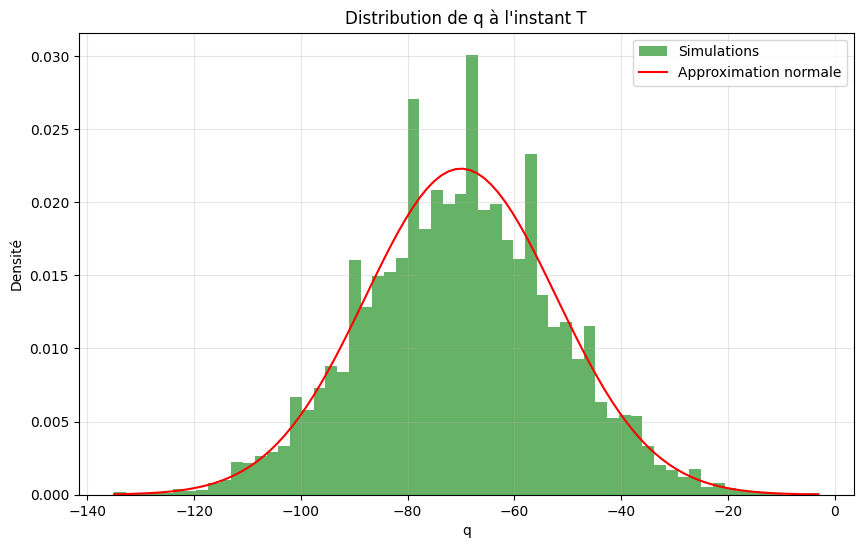

In [39]:
plot_approximation(100, LAMBDA_PLUS, LAMBDA_MINUS , num_simulations=10000, q_0 = Q_0_A)

In [40]:
def stopping_time_distribution(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times, q_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0)
        stopping_times.append(times[-1])
    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus
    shape = q_0**2 / sigma2
    mu_sc = sigma2 / (q_0 * abs(drift))
    plt.figure(figsize=(10, 6))
    X = np.linspace(0.01, max(stopping_times), 300)
    plt.plot(X, sps.invgauss.pdf(X, mu=mu_sc, scale=shape), 'r-', label='Distribution inverse gaussienne théorique')
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='b', label='Simulation Poisson')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour q")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def simulate_brownian_motion_until_zero(drift, variance, q_0=Q_0_A, dt=0.01):
    q = q_0
    t = 0.0
    while q > 0:
        q_prev = q
        t_prev = t
        q += drift * dt + np.sqrt(variance * dt) * np.random.randn()
        t += dt
    frac = q_prev / (q_prev - q)
    return t_prev + frac * dt

def stopping_time_distribution_brownian(drift, variance, q_0=Q_0_A, num_simulations=1000):
    stopping_times = [simulate_brownian_motion_until_zero(drift, variance, q_0) for _ in range(num_simulations)]
    shape = q_0**2 / variance
    mu_sc = variance / (q_0 * abs(drift))
    plt.figure(figsize=(10, 6))
    X = np.linspace(0.01, max(stopping_times), 300)
    plt.plot(X, sps.invgauss.pdf(X, mu=mu_sc, scale=shape), 'r-', label='Distribution inverse gaussienne théorique')
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='m', label='Simulation Brownienne')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro (Brownien)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour le processus brownien")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

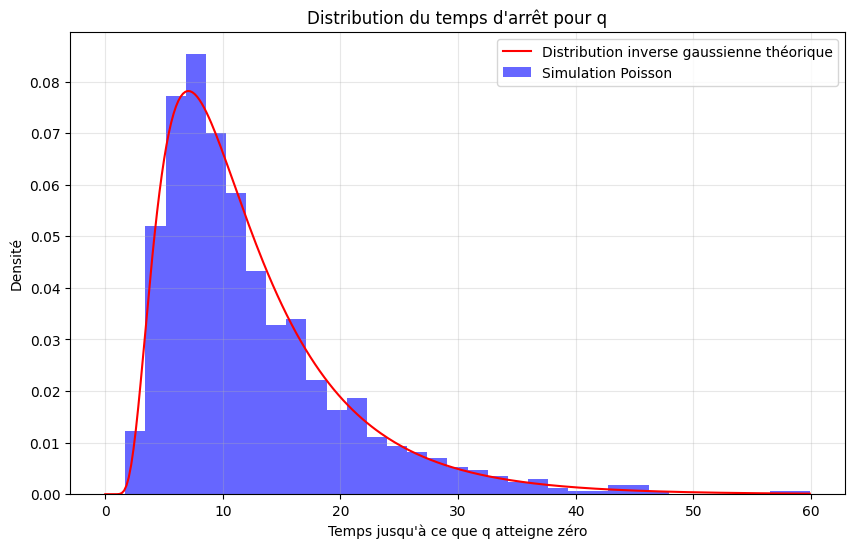

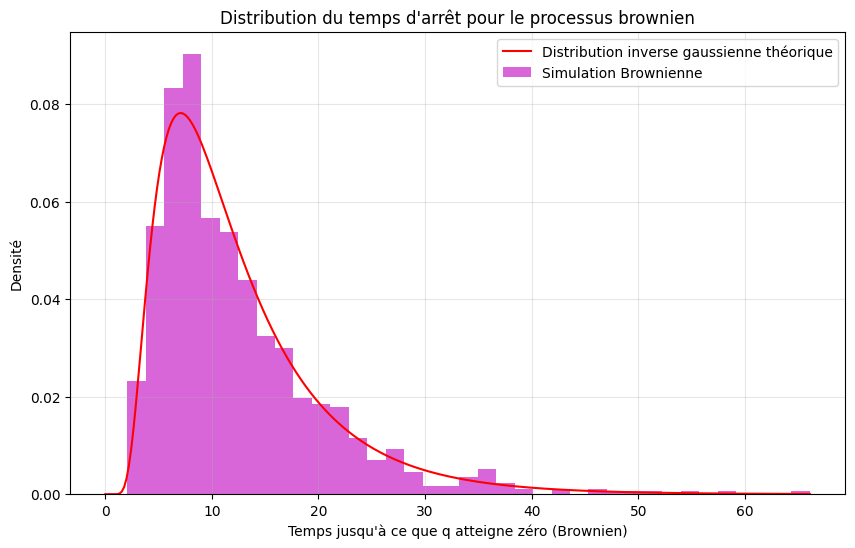

In [41]:
stopping_time_distribution(LAMBDA_PLUS, LAMBDA_MINUS, q_0=Q_0_A, num_simulations=1000)
stopping_time_distribution_brownian(LAMBDA_PLUS - LAMBDA_MINUS, LAMBDA_PLUS + LAMBDA_MINUS, q_0=Q_0_A, num_simulations=1000)

In [48]:
def probability_of_asking_price_reaching_zero_before_bid(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000):
    count_ask_zero_first = 0
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a=q_0_a, q_0_b=q_0_b)
        if times_a[-1] < times_b[-1]:
            count_ask_zero_first += 1
    probability = count_ask_zero_first / num_simulations
    return probability

def plot_proba_as_a_function_of_initial_conditions(lambda_plus, lambda_minus, num_simulations=1000, q_max=10):
    q_0_values = range(1, q_max + 1)
    Q0_A_vals, Q0_B_vals = np.meshgrid(list(q_0_values), list(q_0_values))
    probabilities = np.zeros_like(Q0_A_vals, dtype=float)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            probabilities[j, i] = probability_of_asking_price_reaching_zero_before_bid(
                lambda_plus, lambda_minus, q_0_a=q0_a, q_0_b=q0_b, num_simulations=num_simulations
            )

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(Q0_A_vals, Q0_B_vals, probabilities, cmap='viridis', alpha=0.85)

    ax.set_xlabel('q_0_a')
    ax.set_ylabel('q_0_b')
    ax.set_zlabel('P(ask → 0 first)')  # labelpad pushes it away from the axis
    ax.set_title("Probabilité que l'ask atteigne 0 avant le bid")

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

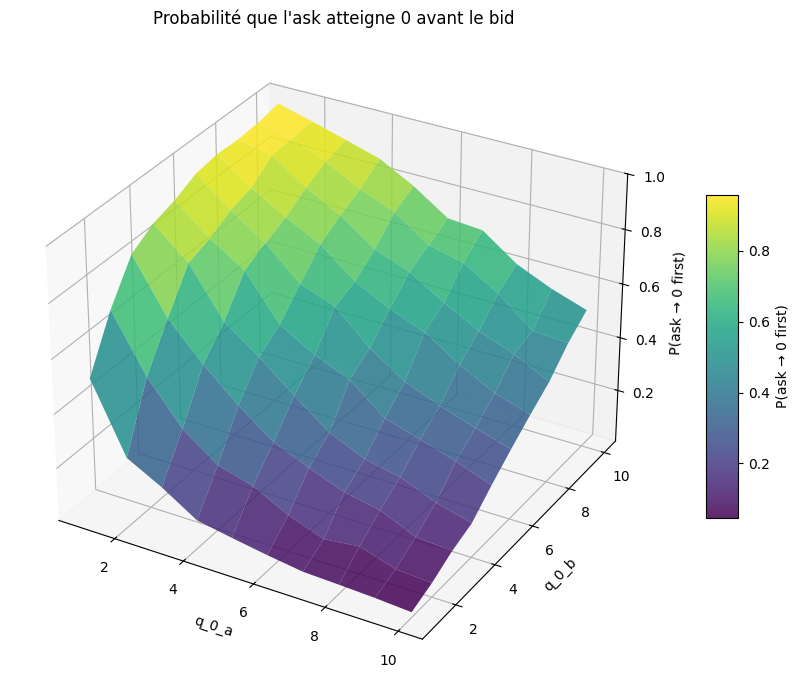

In [50]:
plot_proba_as_a_function_of_initial_conditions(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, q_max=10)

In [44]:
def determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS):
    return (mu_minus * beta - lambda_plus * alpha) / (beta - alpha)

In [53]:
def hawkes_simulation(mu_minus, alpha, beta,lambda_plus = LAMBDA_PLUS, q_0 = Q_0, stopping_condition=lambda q,t: t > T):
    q = q_0
    t = 0
    t_last = 0
    lambda_bar = mu_minus
    lambda_minus_t = mu_minus
    lambda_minus_list = [lambda_minus_t]
    times = [t]
    q_values = [q]
    while not stopping_condition(q, t):
        lambda_bar = max(mu_minus, lambda_minus_t)
        sup_lambda = lambda_bar + lambda_plus
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre = mu_minus + (lambda_minus_t - mu_minus) * np.exp(-beta * (t_prime - t_last))
        lambda_eff = max(lambda_pre, 0)
        U = np.random.rand()
        if U < lambda_plus / sup_lambda:
            q += 1
            t = t_prime
            t_last = t
            lambda_minus_t = lambda_pre - alpha
            times.append(t)
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
        elif U < (lambda_eff+lambda_plus) / sup_lambda:
            q -= 1
            t = t_prime
            t_last = t
            lambda_minus_t = lambda_pre + alpha
            times.append(t)
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
        else:
            lambda_minus_t = lambda_pre
            t_last = t_prime
            t = t_prime
        
    return times, q_values, lambda_minus_list

def plot_hawkes_process(times, q_values):
    plt.figure(figsize=(12, 6))
    plt.step(times, q_values, where='post')
    plt.title('Évolution de q au fil du temps (Hawkes)')
    plt.xlabel('Temps')
    plt.ylabel('q')
    plt.grid()
    plt.show()
    
def distribution_of_stopping_times_hawkes(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times, _, _ = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: q == 0)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='c', label='Simulation Hawkes')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro (Hawkes)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour le processus Hawkes")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
def plot_lambda_minus_over_time(times, lambda_minus_list):
    plt.figure(figsize=(12, 6))
    plt.step(times, lambda_minus_list, where='post')
    plt.title('Évolution de λ⁻ au fil du temps (Hawkes)')
    plt.xlabel('Temps')
    plt.ylabel('λ⁻(t)')
    plt.grid()
    plt.show()

def distribution_last_lambda_minus(T=T, num_simulations=1000, mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0):
    stationnary_lambda_minus = determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus)
    last_lambda_minus_values = []
    for _ in range(num_simulations):
        times, _, lambda_minus_list = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: t > T)
        times_arr = np.array(times)
        idx = np.searchsorted(times_arr, T, side='right') - 1
        lambda_at_T = mu_minus + (lambda_minus_list[idx] - mu_minus) * np.exp(-beta * (T - times[idx]))
        last_lambda_minus_values.append(lambda_at_T)
    plt.figure(figsize=(10, 6))
    plt.hist(last_lambda_minus_values, bins='auto', density=True, alpha=0.6, color='m', label='Simulation Hawkes')
    plt.xlabel("Valeur de λ⁻ à l'instant T")
    plt.ylabel('Densité')
    plt.title("Distribution de λ⁻ à l'instant T pour le processus Hawkes")
    plt.axvline(stationnary_lambda_minus, color='r', linestyle='--', label=f'λ⁻ stationnaire ≈ {stationnary_lambda_minus:.2f}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    

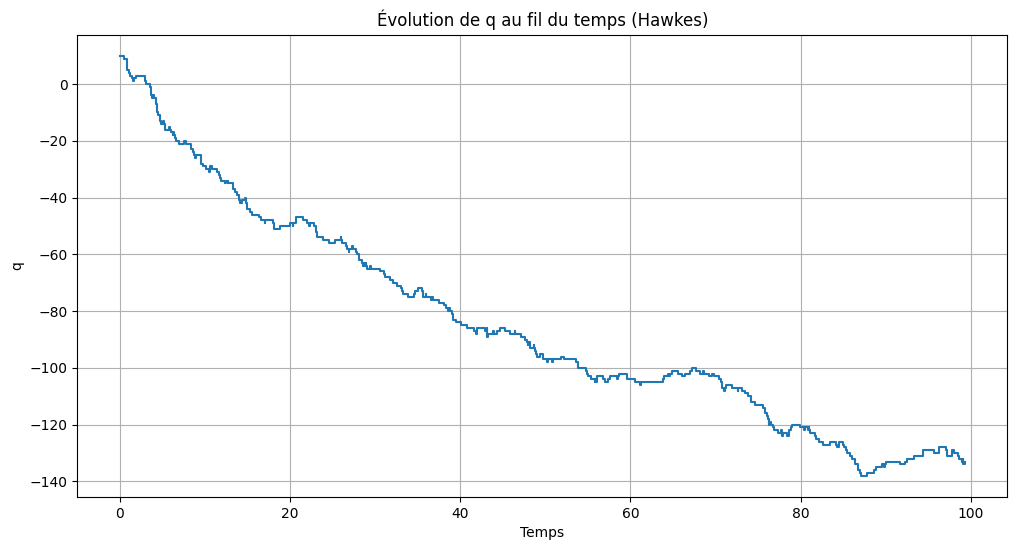

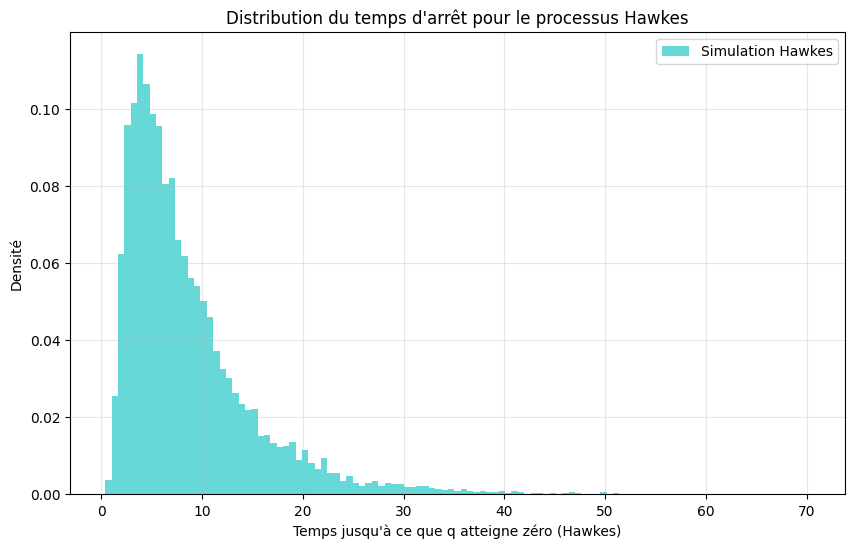

In [54]:
times, q_values, lambda_minus_list = hawkes_simulation(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0, stopping_condition=lambda q,t: t > T)
plot_hawkes_process(times, q_values)
distribution_of_stopping_times_hawkes (mu_minus=2, alpha=0.5, beta=1, num_simulations=10000)


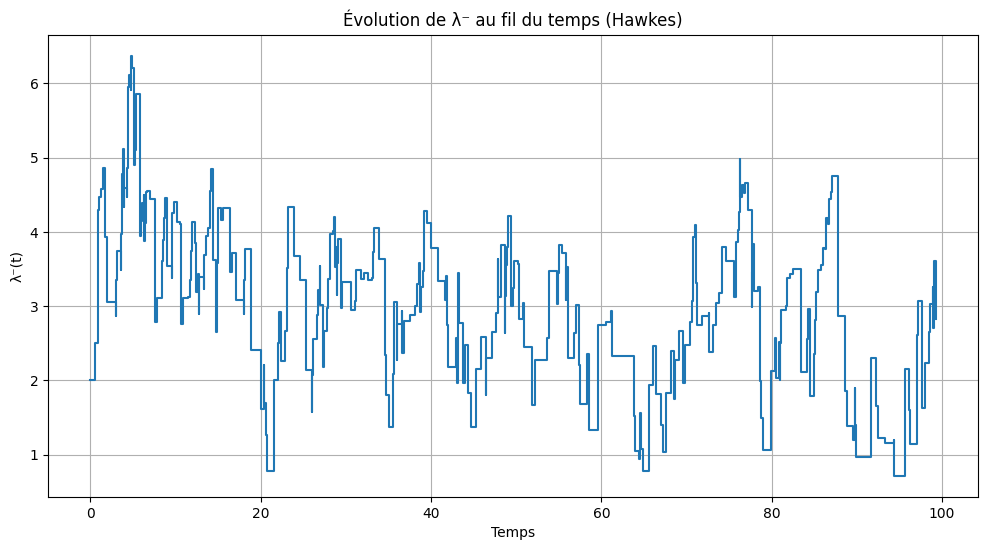

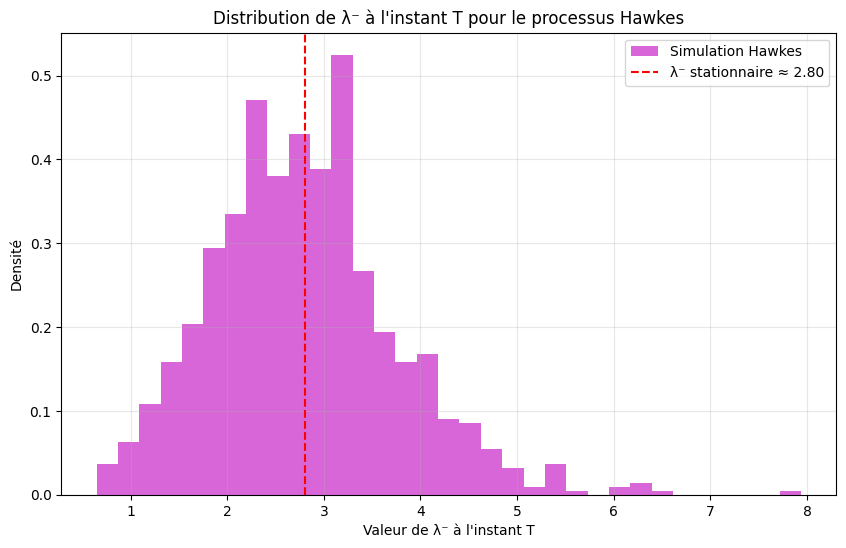

In [55]:
plot_lambda_minus_over_time(times, lambda_minus_list)
distribution_last_lambda_minus(T=1000, num_simulations=1000, mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0)

In [65]:
def simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B):
    q_a = q_0_a
    q_b = q_0_b
    t = 0
    t_last_a = 0
    t_last_b = 0
    lambda_bar_a = mu_minus_a
    lambda_bar_b = mu_minus_b
    lambda_minus_a_t = mu_minus_a
    lambda_minus_b_t = mu_minus_b
    times = [t]
    times_a = [t]
    times_b = [t]
    q_a_values = [q_a]
    q_b_values = [q_b]
    while q_a > 0 and q_b > 0:
        lambda_bar_a = max(mu_minus_a, lambda_minus_a_t)
        lambda_bar_b = max(mu_minus_b, lambda_minus_b_t)
        sup_lambda = lambda_bar_a + lambda_bar_b + lambda_plus_a + lambda_plus_b
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre_a = mu_minus_a + (lambda_minus_a_t - mu_minus_a) * np.exp(-beta * (t_prime - t_last_a))
        lambda_pre_b = mu_minus_b + (lambda_minus_b_t - mu_minus_b) * np.exp(-beta * (t_prime - t_last_b))
        lambda_eff_a = max(lambda_pre_a, 0)
        lambda_eff_b = max(lambda_pre_b, 0)
        U = np.random.rand()
        if U < lambda_plus_a / sup_lambda:
            q_a += 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a - alpha
            times.append(t)
            times_a.append(t)
            q_a_values.append(q_a)
        elif U < (lambda_eff_a+lambda_plus_a) / sup_lambda:
            q_a -= 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a + alpha
            times.append(t)
            times_a.append(t)   
            q_a_values.append(q_a)
        elif U < (lambda_bar_a+lambda_plus_a) / sup_lambda:
            lambda_minus_a_t = lambda_pre_a
            t_last_a = t_prime
            t = t_prime
        elif U < (lambda_bar_a+lambda_plus_a+lambda_plus_b) / sup_lambda:
            q_b += 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b - alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        elif U < (lambda_bar_a+lambda_plus_a+lambda_eff_b+lambda_plus_b) / sup_lambda:
            q_b -= 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b + alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        else:
            lambda_minus_b_t = lambda_pre_b
            t_last_b = t_prime
            t = t_prime
    return times, times_a, times_b, q_a_values, q_b_values


def plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.tight_layout()
    plt.grid()
    plt.show()
    
def plot_stopping_time_distribution_coupled_hawkes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times,_ ,_ , _, _ = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='purple', label='Simulation Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q_a ou q_b atteigne zéro (Hawkes couplé)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour les processus Hawkes couplés")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

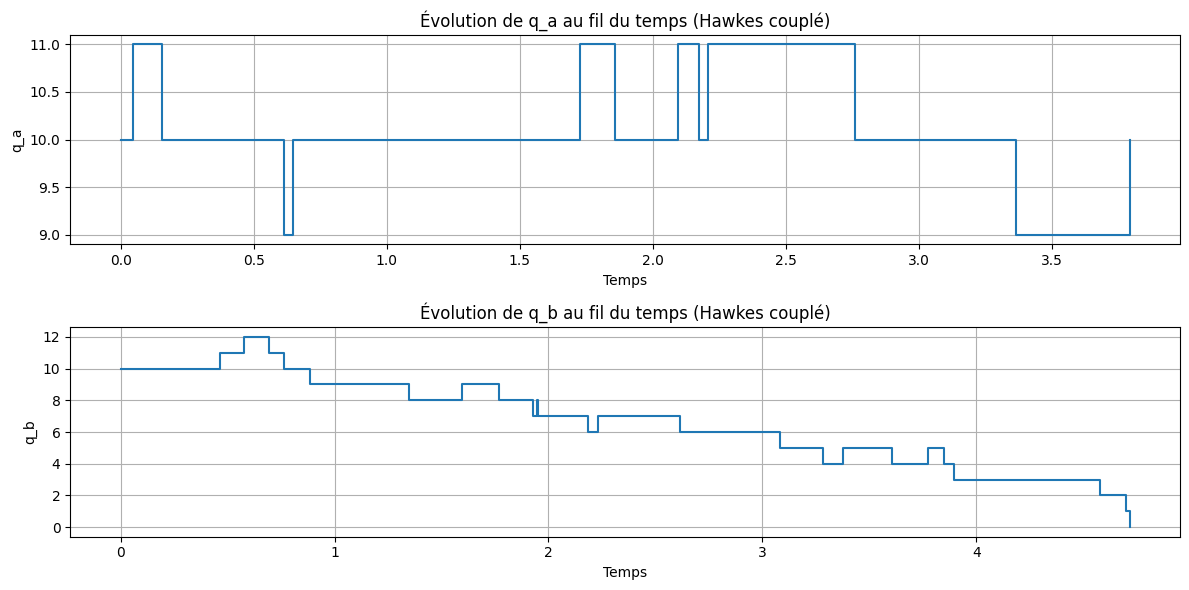

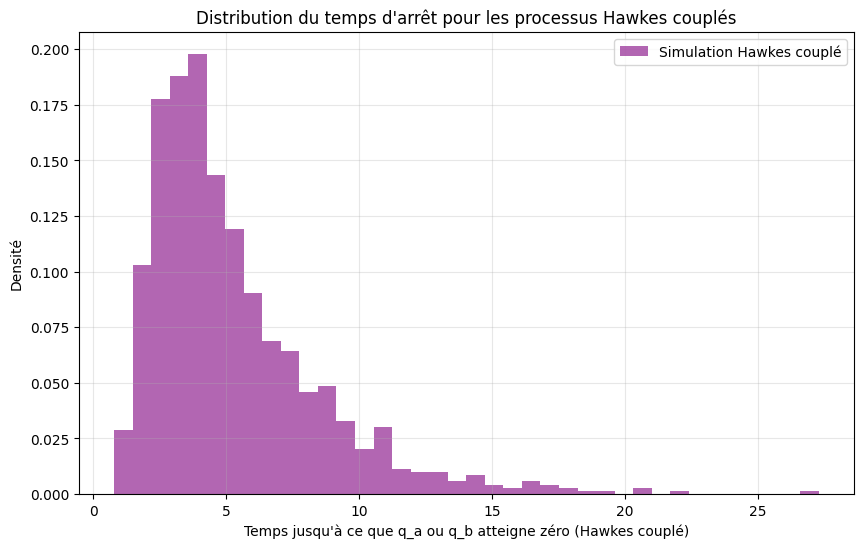

In [66]:
times,times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B)
plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values)
plot_stopping_time_distribution_coupled_hawkes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B)

In [67]:
#comparing all different stopping times from individual poisson, first of two poisson, hawkes and coupled hawkes
def compare_stopping_time_distributions(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000):
    stopping_times_poisson = []
    stopping_times_first_of_two = []
    stopping_times_hawkes = []
    stopping_times_coupled_hawkes = []
    
    for _ in range(num_simulations):
        # Poisson
        times, _ = simulate_only_one_process(lambda_plus, mu_minus, q_0)
        stopping_times_poisson.append(times[-1])
        
        # First of two Poisson
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, mu_minus, q_0_a=q_0, q_0_b=q_0)
        stopping_times_first_of_two.append(min(times_b[-1], times_a[-1]))
        
        # Hawkes
        times_hawkes, _, _ = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: q == 0)
        stopping_times_hawkes.append(times_hawkes[-1])
        
        # Coupled Hawkes
        times_coupled_hawkes, _, _, _, _ = simulated_coupled_hawkes_processes(mu_minus, mu_minus, alpha, beta, lambda_plus, lambda_plus, q_0, q_0)
        stopping_times_coupled_hawkes.append(times_coupled_hawkes[-1])
    
    plt.figure(figsize=(12, 8))
    plt.hist(stopping_times_poisson, bins='auto', density=True, alpha=0.6, color='b', label='Poisson individuel')
    plt.hist(stopping_times_first_of_two, bins='auto', density=True, alpha=0.6, color='g', label='Premier des deux Poisson')
    plt.hist(stopping_times_hawkes, bins='auto', density=True, alpha=0.6, color='r', label='Hawkes')
    plt.hist(stopping_times_coupled_hawkes, bins='auto', density=True, alpha=0.6, color='purple', label='Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro")
    plt.ylabel('Densité')
    plt.title("Comparaison des distributions du temps d'arrêt")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

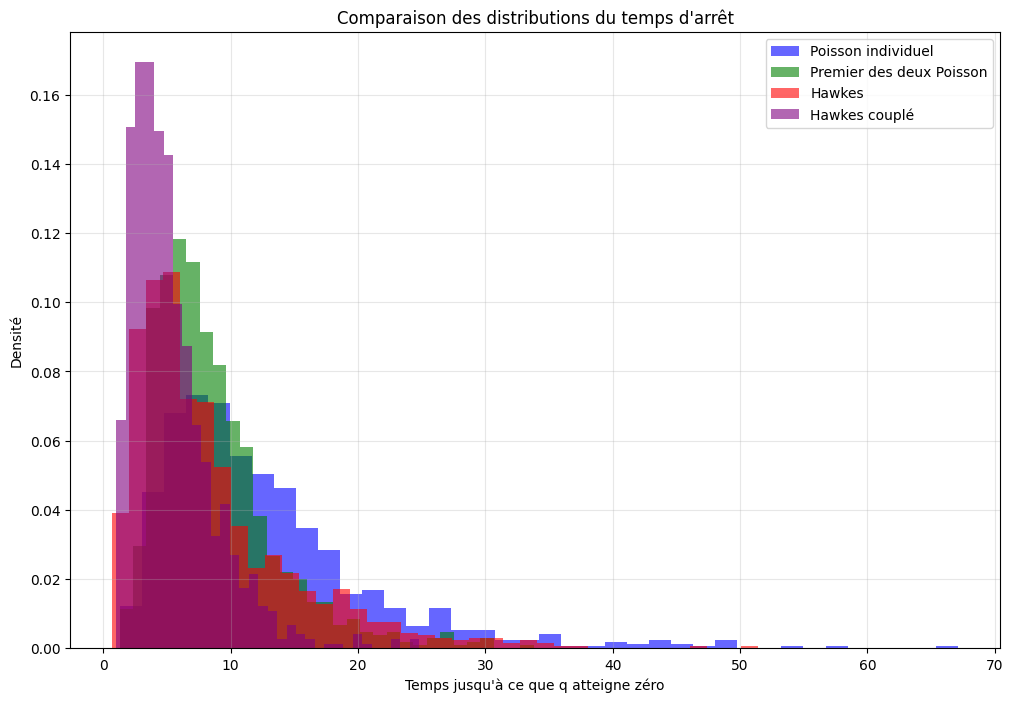

In [68]:
compare_stopping_time_distributions(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000)